# Practice Set 15: Capstone Visualizations

**Objective:** Create three publication-quality visualizations that support your capstone project's narrative.

---

## Learning Objectives
By completing this problem set, you will:
- Select appropriate visualization types for different data and questions
- Apply ggplot2 best practices for clear, effective communication
- Create visualizations that tell a coherent story about your data
- Write captions that help readers interpret your figures

---

## Instructions

1. **Use your own capstone data** for all three visualizations
2. Each visualization should serve a **different purpose** (see requirements below)
3. All visualizations must include:
   - Clear, descriptive title
   - Labeled axes with units where appropriate
   - Legend (if applicable)
   - Clean theme (e.g., `theme_minimal()`, `theme_bw()`)
4. Write a brief caption (2-3 sentences) explaining what each visualization shows

---

## Setup
Load the required packages and your capstone data.

In [3]:
# Load packages
library(tidyverse)
library(scales)      # For nice axis formatting
library(ggthemes)    # Optional: additional themes
library(sf)
library(terra)
library(tidyterra)
library(ggnewscale)   
# Load library to calculate acres
library(units)

# Load your capstone data
municipalities <- st_read("/home/user/eds_certificate_capstone/agrivoltaics_in_ri/data/raw_data/BND_Municipalities_1997_spf/ri_municipalities_1997.shp")

ri_existing_solar_farms <- st_read("/home/user/eds_certificate_capstone/agrivoltaics_in_ri/data/raw_data/solar_farms_ri/solar_farms_ri.shp")

land_use <- st_read("/home/user/eds_certificate_capstone/agrivoltaics_in_ri/data/raw_data/land_cover_use_2020/land_cover_use_2020.shp")%>% 
  filter(Descr_2020 %in% c("Idle Agriculture (abandoned fields and orchards)", "Cropland (tillable)", "Pasture (agricultural not suitable for tillage)", "Orchards, Groves, Nurseries"))

glimpse(municipalities)
glimpse(ri_existing_solar_farms)
glimpse(land_use)

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.5.1
✔ ggplot2   3.5.2     ✔ tibble    3.3.0
✔ lubridate 1.9.4     ✔ tidyr     1.3.1
✔ purrr     1.1.0     


── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors



Attaching package: ‘scales’




The following object is masked from ‘package:purrr’:

    discard




The following object is masked from ‘package:readr’:

    col_factor




...

Reading layer `solar_farms_ri' from data source 
  `/home/user/eds_certificate_capstone/agrivoltaics_in_ri/data/raw_data/solar_farms_ri/solar_farms_ri.shp' 
  using driver `ESRI Shapefile'
Simple feature collection with 1417 features and 3 fields
Geometry type: MULTIPOLYGON
Dimension:     XY, XYZ
Bounding box:  xmin: -189389.9 ymin: 95886.7 xmax: 742273.5 ymax: 649793.5
z_range:       zmin: 0 zmax: 0
Projected CRS: NAD83 / Rhode Island (ftUS)


Reading layer `land_cover_use_2020' from data source 
  `/home/user/eds_certificate_capstone/agrivoltaics_in_ri/data/raw_data/land_cover_use_2020/land_cover_use_2020.shp' 
  using driver `ESRI Shapefile'
Simple feature collection with 68618 features and 5 fields
Geometry type: POLYGON
Dimension:     XY
Bounding box:  xmin: 220000 ymin: 23051.56 xmax: 434591.9 ymax: 343511.1
Projected CRS: NAD83 / Rhode Island (ftUS)


Rows: 396
Columns: 11
$ RITOWN5K_  <dbl> 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 13, 14, 15, 16, 19, 20, 21,…
$ RITOWN5K_I <dbl> 380, 1, 2, 3, 381, 4, 5, 6, 7, 8, 10, 382, 383, 11, 14, 384…
$ NAME       <chr> "CUMBERLAND", "WOONSOCKET", "NORTH SMITHFIELD", "BURRILLVIL…
$ MCD        <dbl> 20, 80, 55, 5, 45, 75, 35, 10, 60, 50, 40, 65, 25, 70, 30, …
$ CFIPS      <dbl> 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 7, 10, 7, 7, 7, 7, 7, 7, 7…
$ COUNTY     <chr> "PROVIDENCE", "PROVIDENCE", "PROVIDENCE", "PROVIDENCE", "PR…
$ OSP        <dbl> 8, 39, 25, 3, 17, 31, 13, 4, 26, 24, 16, 28, 10, 30, 12, 28…
$ CFIPS_MCD  <dbl> 7020, 7080, 7055, 7005, 7045, 7075, 7035, 7010, 7060, 7050,…
$ TWNCODE    <chr> "CU", "WO", "NS", "BU", "LI", "SM", "GL", "CF", "PA", "NP",…
$ LAND       <chr> "Y", "Y", "Y", "Y", "Y", "Y", "Y", "Y", "Y", "Y", "Y", "Y",…
$ geometry   <POLYGON [US_survey_foot]> POLYGON ((339469.7 340510.4..., POLYGO…


Rows: 1,417
Columns: 4
$ NameplateC <dbl> 3.3, 3.3, 0.0, 1.8, 0.0, 2.0, 4.8, 4.8, 0.0, 0.0, 1.2, 0.0,…
$ OperatingM <dbl> 10, 10, 6, 12, 10, 12, 11, 11, 3, 9, 8, 9, 9, 3, 10, 5, 6, …
$ OperatingY <dbl> 2020, 2020, 2022, 2020, 2021, 2017, 2020, 2020, 2020, 2019,…
$ geometry   <MULTIPOLYGON [US_survey_foot]> MULTIPOLYGON Z (((283546.9 ..., M…


Rows: 5,431
Columns: 6
$ State      <chr> "CT", "CT", "CT", "CT", "CT", "CT", "CT", "CT", "CT", "CT",…
$ LULC_2020  <int> 210, 210, 210, 210, 210, 210, 210, 210, 210, 210, 210, 210,…
$ Descr_2020 <chr> "Pasture (agricultural not suitable for tillage)", "Pasture…
$ Acres_2020 <dbl> 15.90290, 0.93909, 2.10937, 1.26342, 8.53504, 1.75153, 14.3…
$ symbology_ <chr> "Agricultural Land", "Agricultural Land", "Agricultural Lan…
$ geometry   <POLYGON [US_survey_foot]> POLYGON ((232354.4 91241.78..., POLYGO…


---

## Visualization 1: Distribution or Composition (15 points)

**Purpose:** Show how your data is distributed or composed.

### Suggested plot types:

- **Histogram** – distribution of a continuous variable
- **Density plot** – smoothed distribution
- **Boxplot** – distribution across groups
- **Bar chart** – counts or proportions of categories
- **Pie/donut chart** – composition (use sparingly)

### Requirements:

- [ ] Shows the distribution OR composition of at least one key variable
- [ ] Includes appropriate title and axis labels
- [ ] Uses color meaningfully (not just decoratively)
- [ ] Caption explains what pattern or insight the reader should notice

### Questions to consider:

- What is the shape of your data's distribution? (Normal? Skewed? Bimodal?)
- Are there outliers that need explanation?
- How do distributions differ across groups?



Warning message:
“attribute variables are assumed to be spatially constant throughout all geometries”


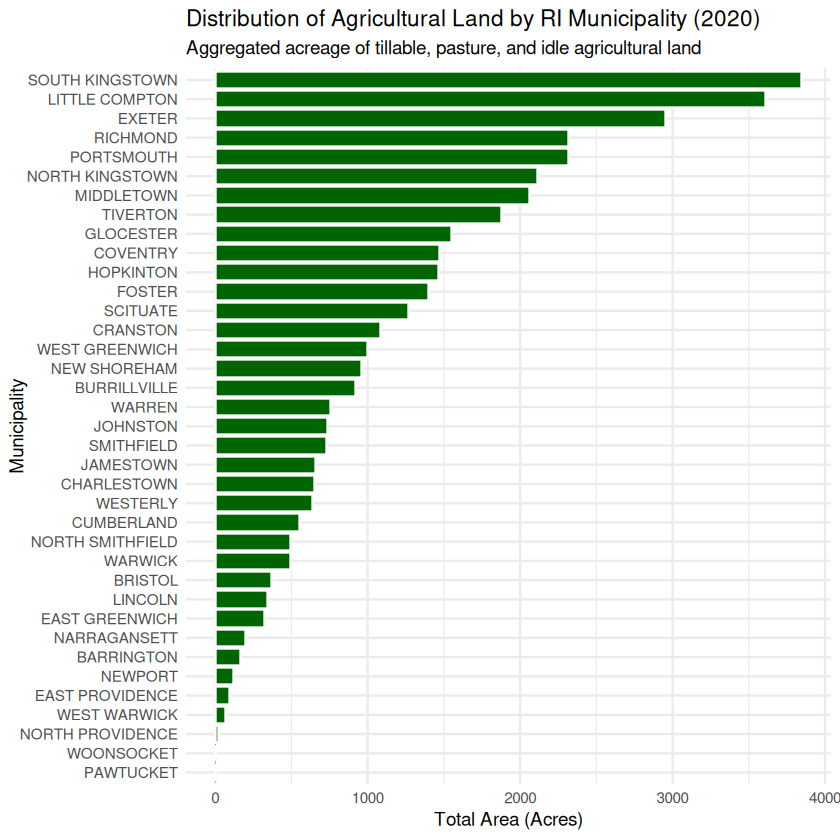

In [4]:
# VISUALIZATION 1: Distribution or Composition

# cut the land_use polygons by the municipality boundaries
intersections <- st_intersection(land_use, municipalities)

# calculate the area of the new intersected pieces - farmland between town lines
intersections$area_sqm <- st_area(intersections)

# Create a summary plot
muni_farm_land_use <- intersections %>%
  st_drop_geometry() %>% # Convert to a standard table for faster math
  group_by(NAME) %>%
  summarize(Total_Acres = sum(Acres_2020, na.rm = TRUE)) %>%
  arrange(desc(Total_Acres))

# create a bar chart of total farmland acreage by municipality
viz1 <- ggplot(muni_farm_land_use, aes(x = reorder(NAME, Total_Acres), y = Total_Acres)) +
  geom_col(fill = "darkgreen", color = "white") +
     coord_flip() +  # Flip the chart to make municipality names readable
  labs(
    title = "Distribution of Agricultural Land by RI Municipality (2020)",
    subtitle = "Aggregated acreage of tillable, pasture, and idle agricultural land",
    x = "Municipality",
    y = "Total Area (Acres)"
  ) +
  theme_minimal()

viz1

### Caption for Visualization 1

*Write 2-3 sentences explaining what this visualization shows and why it matters for your capstone.*

**Figure 1:** This visualization presents a breakdown of total agricultural acreage across Rhode Island municipalities, specifically highlighting areas containing tillable, pasture, or idle farmland as of 2020. By ranking municipalities by their total acreage, the chart identifies the regions with the greatest "land capital" for potential agrivoltaic development. It serves as the foundational layer of the agrivoltaics suitability analysis. 


---

## Visualization 2: Relationship or Comparison (15 points)

**Purpose:** Show a relationship between variables OR compare groups.

### Suggested plot types:
- **Scatterplot** – relationship between two continuous variables
- **Line plot** – trends over time or sequence
- **Grouped bar chart** – comparing categories across groups
- **Faceted plots** – same relationship across subgroups
- **Correlation heatmap** – relationships among multiple variables

### Requirements:
- [ ] Shows a relationship between at least two variables OR compares groups
- [ ] Includes appropriate title and axis labels
- [ ] Uses `geom_smooth()`, trend lines, or reference lines if appropriate
- [ ] Caption explains the relationship or comparison and its significance

### Questions to consider:
- Is the relationship positive, negative, or nonlinear?
- Are there subgroups that behave differently?
- What is the practical significance of this relationship for your capstone question?

Warning message:
“attribute variables are assumed to be spatially constant throughout all geometries”


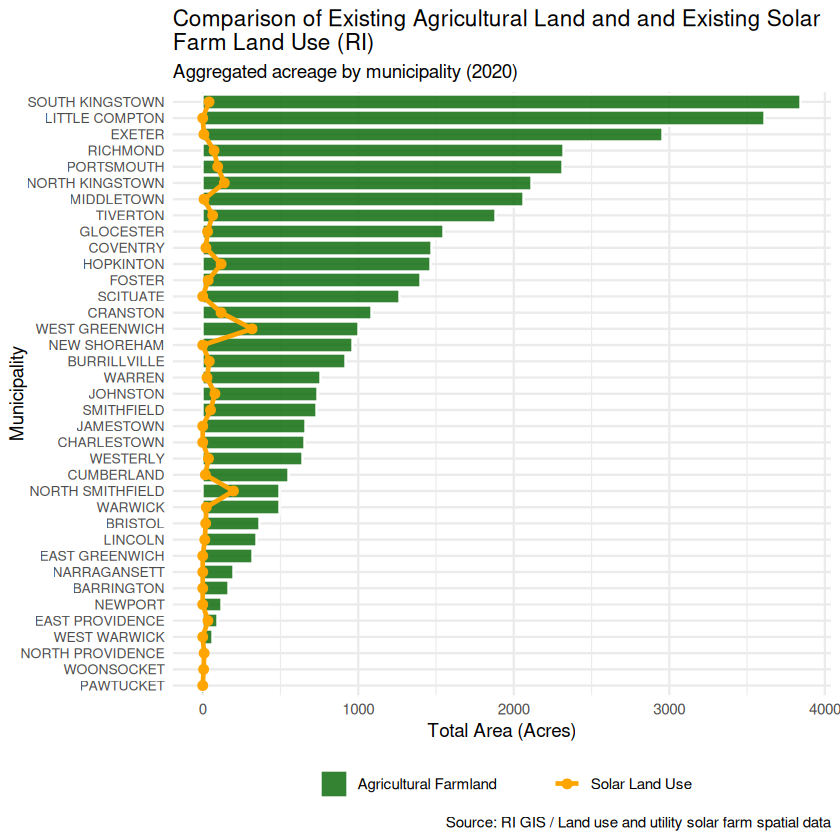

In [5]:
# The Solar Farm dataset is in 3D (xyz) and needs to be 2D (xy) to match the municipalities dataset.
    # Clean the solar farms data by dropping the Z dimension
ri_existing_solar_farms <- ri_existing_solar_farms %>%
    st_zm() %>%
    st_filter(municipalities) %>%
    mutate(total_farm_area_acres = as.numeric(set_units(st_area(.), acre)))

# Spatial Intersection: Calculate the area of fragments that fall within municipality boundaries
intersections <- st_intersection(ri_existing_solar_farms, municipalities) %>%
    mutate(
        fragment_area_acres = as.numeric(set_units(st_area(.), acre)),
        adjusted_mw = (fragment_area_acres / total_farm_area_acres) * NameplateC)

# Create a summary plot
muni_solar <- intersections %>%
    st_drop_geometry() %>%
    group_by(NAME) %>%
    summarize(
        total_acres = sum(fragment_area_acres, na.rm = TRUE),
        total_mw = sum(adjusted_mw, na.rm = TRUE)) %>%
    arrange(desc(total_acres))

# Join the datasets - muni_solar and muni_farm_land_use
    # Using a left_join to keep all municipalities that have farmland data
combined_muni_data <- muni_farm_land_use %>%
  left_join(muni_solar, by = "NAME") %>%
  # Replace NA solar values with 0 (for municipalities with no solar farms)
  mutate(total_acres = replace_na(total_acres, 0))

# Creating the combined visualization
viz2 <- ggplot(combined_muni_data, aes(x = reorder(NAME, Total_Acres))) +
  # Bar chart for Agricultural Land Use
  geom_col(aes(y = Total_Acres, fill = "Agricultural Farmland"), 
           color = "white", alpha = 0.8) +
  
# Line plot for Solar Farm Use
  # 'group = 1' for geom_line ecause using a categorical x-axis
  geom_line(aes(y = total_acres, color = "Solar Land Use", group = 1), 
            linewidth = 1) +
  geom_point(aes(y = total_acres, color = "Solar Land Use"), 
             size = 2) +
# Formatting
  coord_flip() +
  scale_fill_manual(name = "", values = c("Agricultural Farmland" = "darkgreen")) +
  scale_color_manual(name = "", values = c("Solar Land Use" = "orange")) +
  labs(
    title = "Comparison of Existing Agricultural Land and and Existing Solar \nFarm Land Use (RI)",
    subtitle = "Aggregated acreage by municipality (2020)",
    x = "Municipality",
    y = "Total Area (Acres)",
    caption = "Source: RI GIS / Land use and utility solar farm spatial data"
  ) +
  theme_minimal() +
  theme(
    legend.position = "bottom",
    axis.text.y = element_text(size = 8)
  )

viz2

### Caption for Visualization 2

*Write 2-3 sentences explaining what this visualization shows and why it matters for your capstone.*

**Figure 2:** This visualization illustrates the spatial intersection and scale of existing agricultural land and current solar farm footprints across Rhode Island municipalities. By comparing total farmland acreage \(green bars\) against existing solar land use \(orange line\), the chart identifies a nonlinear relationship where some towns remain heavily agricultural with minimal solar development, while others show early adoption of solar on or near lands zoned for agricultural use.

Municipalities where the orange line \(solar\) and green bars \(farmland\) both show greater area use for ag and solar, are areas of high interest. These locations may already have the grid proximity and landowner interest necessary for agrivoltaics, making them prime candidates for dual\-use optimization.


---

## Visualization 3: Change Over Time or Space (15 points)

**Purpose:** Show how something changes across time, geography, or another ordered dimension.

### Suggested plot types:
- **Line chart** – trends over time
- **Area chart** – cumulative changes over time
- **Map** – spatial patterns (if you have geographic data)
- **Slope chart** – change between two time points
- **Faceted time series** – trends across multiple groups

### Requirements:
- [ ] Shows change across time, space, or another meaningful sequence
- [ ] Time axis is properly formatted (if applicable)
- [ ] Key events, thresholds, or reference points are annotated (if relevant)
- [ ] Caption explains the trend and its implications for your capstone

### Questions to consider:
- Is there a clear trend (increasing, decreasing, cyclical)?
- Are there notable events or breakpoints?
- How does this temporal/spatial pattern connect to your research question?

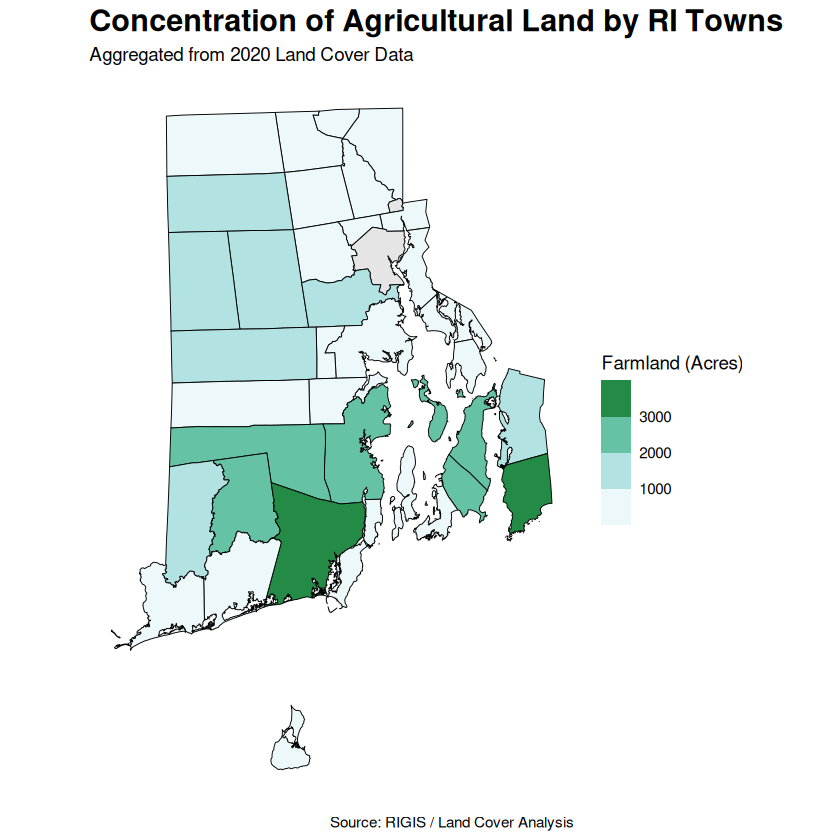

In [8]:
# VISUALIZATION 3: Change Over Time or Space
# Your code here

# Join the summary back to the spatial municipality data
muni_map_data <- municipalities %>%
  left_join(muni_farm_land_use, by = "NAME") %>%
st_transform(3438)

# Map the ata set
viz3 <- ggplot(data = muni_map_data) +
  geom_sf(aes(fill = Total_Acres), color = "black", size = 0.2
  ) +
  scale_fill_fermenter(
    palette = "BuGn",
    direction = 1,
    na.value = "grey90", # Distinct color for missing data
    n.breaks = 5,  # creates 5 discrete bins
    name = "Farmland (Acres)"
  ) +
  theme_minimal() +
  labs(title = "Concentration of Agricultural Land by RI Towns",
       subtitle = "Aggregated from 2020 Land Cover Data", 
       caption = "Source: RIGIS / Land Cover Analysis"
 ) +
  theme(
    plot.title = element_text(size = 18, face = "bold"),
    axis.text = element_blank(), 
    axis.title = element_blank(),  
    panel.grid = element_blank())

viz3

### Caption for Visualization 3

*Write 2-3 sentences explaining what this visualization shows and why it matters for your capstone.*

**Figure 3:** The visual reveals a clear spatial concentration of agricultural land in Rhode Island’s southern and western rural corridors, highlighting municipalities like South Kingstown and Exeter as primary agricultural hubs. Identifying these high\-acreage clusters is important to this capstone as it creates a baseline geography where agrivoltaics are most viable, narrowing the search area for layering of topography and grid proximity data. By pinpointing these regions of high agricultural land use, I can focus my analysis on the locations where dual\-use energy systems will have the most significant impact on land preservation.


---

## Reflection Questions (5 points)

Answer the following questions in 2-4 sentences each.

### Question 1

**How do your three visualizations work together to tell a story about your capstone project?**

_These three visuals work together to illustrate which municipalities in Rhode Island my capstone should focus on when analyzing topography and grid proximity. These are my initial observations that have helped me narrow the project._ 


### Question 2

**Which visualization was most challenging to create, and why?**

_Visual 2 was the most challenging because it required bridging the gap between raw spatial data and statistical analysis. Beyond filtering and intersecting complex polygons, I had to normalize different datasets and execute unit conversions \(USft to acres\). The difficulty wasn't just in the data cleaning, but in the critical thinking required to transform fragmented geospatial layers into a cohesive tabular format suitable for graphing._


### Question 3

**What is one thing you would improve about your visualizations if you had more time?**

_I would specifically improve the map of Agricultural Land Use by RI Municipality by identifying the top 5 towns with the greatest acreage of zoned farmland, and labeling their town names. I would also spend more time crafting descriptive titles and source labels._ 


---

## Grading Rubric (50 points total)

| Component | Points | Criteria |
|-----------|--------|----------|
| Visualization 1 | 15 | Appropriate type, clear labels, meaningful use of color, insightful caption |
| Visualization 2 | 15 | Shows relationship/comparison clearly, proper formatting, informative caption |
| Visualization 3 | 15 | Shows change effectively, proper time/space formatting, relevant caption |
| Reflection | 5 | Thoughtful answers demonstrating understanding of visualization choices |

### What makes a visualization "publication quality"?
- Readable fonts and appropriate sizing
- Clear hierarchy (title > subtitle > labels > caption)
- Minimal chart junk (no unnecessary gridlines, borders, or decoration)
- Accessible colors (consider colorblind-friendly palettes)
- Self-contained (a reader can understand it without reading surrounding text)

---

## Helpful Code Snippets

### Formatting dates on x-axis
```r
scale_x_date(date_labels = "%b %Y", date_breaks = "3 months")
```

### Adding a trend line
```r
geom_smooth(method = "lm", se = FALSE, color = "red")
```

### Faceting by a variable
```r
facet_wrap(~category_variable, scales = "free_y")
```

### Colorblind-friendly palette
```r
scale_color_brewer(palette = "Set2")
scale_fill_viridis_d()
```

### Adding annotations
```r
annotate("text", x = date_value, y = y_value, label = "Event", hjust = 0)
geom_vline(xintercept = as.Date("2020-03-15"), linetype = "dashed")
```

### Saving high-resolution figures
```r
ggsave("figure1.png", viz1, width = 8, height = 6, dpi = 300)
```

---

## Submission

Submit the following:
1. This completed notebook (.ipynb file)
2. Three separate image files of your visualizations (.png, 300 dpi)

**Naming convention:** `LastName_FirstName_capstone_viz.ipynb`